Testing how to plot race lap times for a single driver.

Fetching Data for 2025-1-5553


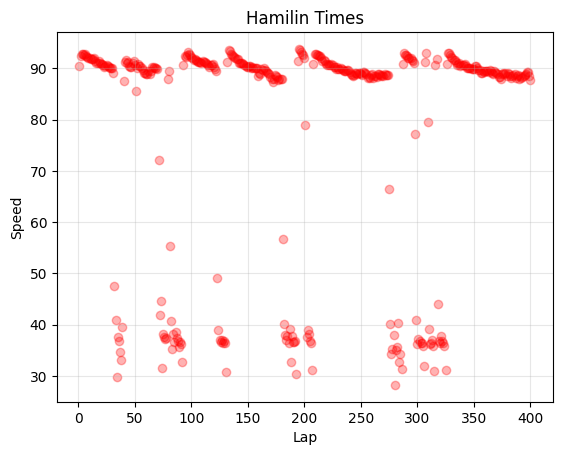

In [2]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]


# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

real_laps = race.telemetry.lap_times[race.telemetry.lap_times['Lap']>0]
lap_times_table = real_laps.sort_values('Lap')
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]

lap_speeds = lap_speeds.sort_values('Lap')

# 
plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='r', alpha=0.3)
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()


# Need to 

Plot lap-time distributions — green-flag laps cluster around one peak, pit-stop and caution laps form a long right tail

Fetching Data for 2025-1-5553


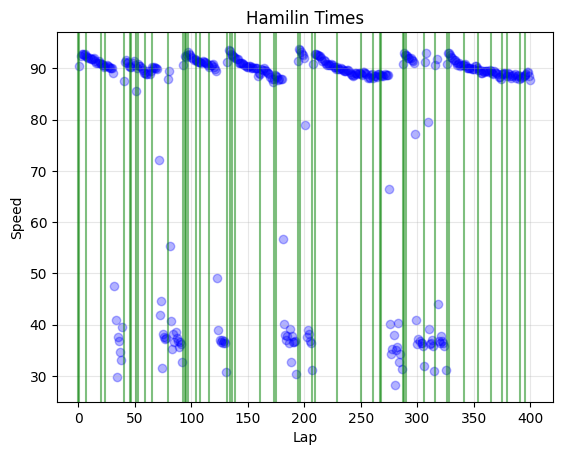

In [16]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

# Speed per lap for one racer
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]
lap_speeds = lap_speeds.sort_values('Lap')

# vline for each lap that is green lap
race.telemetry.events['Lap'] = pd.to_numeric(race.telemetry.events['Lap'], errors='coerce')
race_events = race.telemetry.events[race.telemetry.events['Lap'] > 0]
events_table_sorted = race_events.sort_values('Lap')

green_laps = race.telemetry.events.loc[
    race.telemetry.events['Flag'] == 'Green',
    ['Lap']
]


plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
for lap in green_laps['Lap']:
    plt.axvline(x=lap, color='green', alpha=0.5, linestyle='-')
plt.axvline
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()

Now adding caution laps

Fetching Data for 2025-1-5553


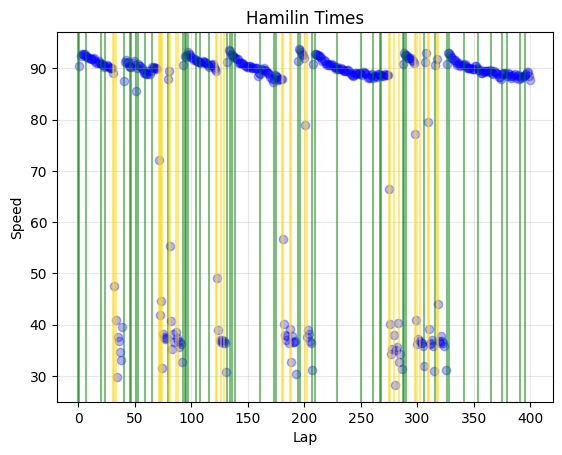

In [ ]:
import pandas as pd
from pynascar import Schedule, Race, set_options, get_settings
from pynascar.driver import DriversData
import numpy as np
import matplotlib.pyplot as plt

# Enable local caching for faster repeated runs
set_options(cache_enabled=True, cache_dir=".cache/", df_format="parquet")

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553 

# Series: 1=Cup, 2=Xfinity, 3=Trucks
year = 2025
series_id = 1
race_id = 5553          

# Schedules
schedule = Schedule(year, series_id)
schedule.data.head()

martinsville_races = schedule.data[schedule.data['track_name'].str.contains('Martinsville', na=False)]

# Race data (use reload=True to force network fetch even if cached)
race = Race(year, series_id, race_id, reload=True)

# Speed per lap for one racer
lap_speeds = race.telemetry.lap_times.loc[
    race.telemetry.lap_times['driver_name'] == 'Denny Hamlin',
    ['Lap', 'lap_speed']
]
lap_speeds = lap_speeds.sort_values('Lap')

# vline for each lap that is green lap
race.telemetry.events['Lap'] = pd.to_numeric(race.telemetry.events['Lap'], errors='coerce')
race_events = race.telemetry.events[race.telemetry.events['Lap'] > 0]
events_table_sorted = race_events.sort_values('Lap')

colored_laps = race.telemetry.events.loc[
    race.telemetry.events['Flag'].isin(['Green', 'Yellow']),
    ['Flag','Lap']
]

plt.scatter(x= lap_speeds['Lap'], y= lap_speeds['lap_speed'],c='b', alpha=0.3)
# a zip pairs up multi iterables element by element 
for lap, flag in zip(colored_laps['Lap'], colored_laps['Flag']):
    if flag == 'Green':
        plt.axvline(x=lap, color='green', alpha=0.5, linestyle='-')
    elif flag == 'Yellow':
        plt.axvline(x=lap, color='gold', alpha=0.5, linestyle='-')
plt.axvline
plt.ylabel('Speed')
plt.xlabel('Lap')
plt.title('Hamilin Times')
plt.grid(True, alpha=0.3)
plt.show()

Adding pit stops 